<a href="https://colab.research.google.com/github/tasneem1865/Deep-Learning-Lab/blob/main/Practical_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

23070521162 - Tasneem Sadikot

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
data = pd.read_csv(r"/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.columns = data.columns.str.strip().str.lower()
data.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Remove customer ID if present
if "customerid" in data.columns:
    data = data.drop("customerid", axis=1)

# Convert the target to numeric labels
data["churn"] = data["churn"].str.strip().str.lower().map({"no": 0, "yes": 1})

# One-hot encode every remaining categorical feature except the target
categorical_columns = [
    column_name
    for column_name in data.select_dtypes(include=["object"]).columns
    if column_name != "churn"
]
data = pd.get_dummies(data, columns=categorical_columns)

# Separate features and target
X = data.drop("churn", axis=1)
y = data["churn"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 5634
Testing Samples: 1409


In [5]:
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │       210,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,105 (824.63 KB)

 Trainable params: 211,105 (824.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7768 - loss: 0.4732 - val_accuracy: 0.7986 - val_loss: 0.4162
Epoch 2/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8028 - loss: 0.4328 - val_accuracy: 0.8101 - val_loss: 0.4137
Epoch 3/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8067 - loss: 0.4158 - val_accuracy: 0.8030 - val_loss: 0.4147
Epoch 4/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8145 - loss: 0.3997 - val_accuracy: 0.7835 - val_loss: 0.4251
Epoch 5/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8283 - loss: 0.3843 - val_accuracy: 0.7968 - val_loss: 0.4289
Epoch 6/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8480 - loss: 0.3499 - val_accuracy: 0.8066 - val_loss: 0.4238
Epoch 7/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8868 - loss: 0.2796 - val_accuracy: 0.7480 - val_loss: 0.4817
Epoch 8/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9343 - loss: 0.1823 -

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7410 - loss: 0.7114
Test Loss: 0.7113732695579529
Test Accuracy: 0.7409510016441345


In [9]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

print("Predicted Values:")
print(predictions.flatten())

print("\nActual Values:")
print(y_test.values)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Predicted Values:
[1 0 0 ... 0 0 0]

Actual Values:
[1 0 0 ... 0 0 1]


In [10]:
print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.7409510290986515

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1036
           1       0.51      0.43      0.47       373

    accuracy                           0.74      1409
   macro avg       0.66      0.64      0.65      1409
weighted avg       0.73      0.74      0.73      1409


Confusion Matrix
[[885 151]
 [214 159]]


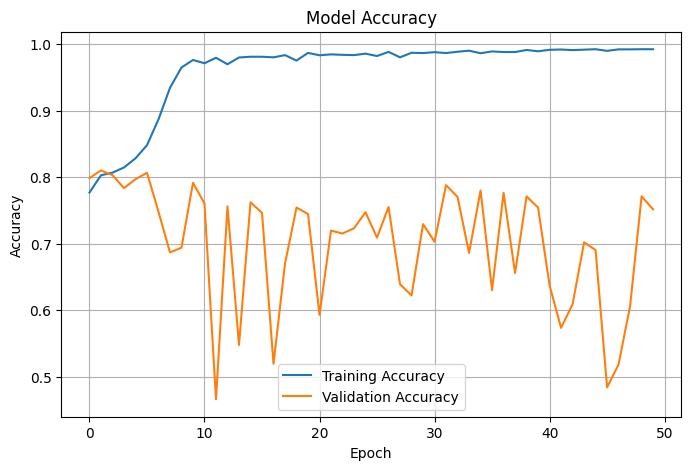

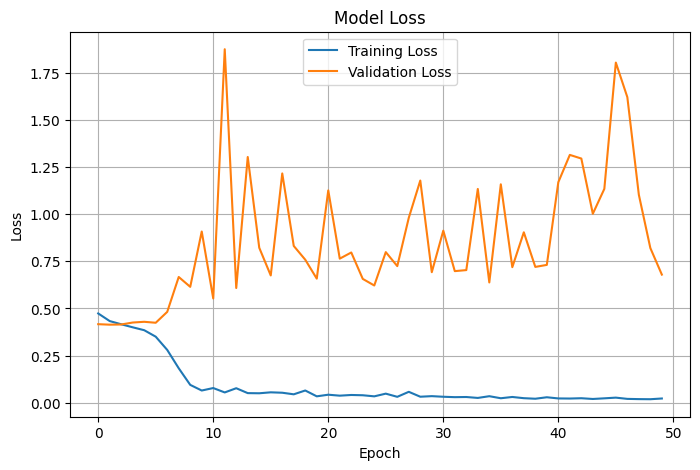

In [11]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)
plt.show()